In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter
from scipy.stats import chi2, t
from scipy.stats import chisquare, geom, ks_2samp
import scipy.stats as stats
import time
np.random.seed(42)

## Part 1

In [2]:
# exponential using inverse formula 
def sample_exponential(lam):
    U = np.random.uniform()
    return -np.log(U) / lam

# normal using box muller 
def sample_normal(mu, sigma):
    U1 = np.random.uniform()
    U2 = np.random.uniform()

    R = np.sqrt(-2 * np.log(U1))
    theta = 2 * np.pi * U2

    Z1 = R * np.cos(theta)
    # we want to sample just one, so we don't get the Z2 value using the sin

    return mu + sigma * Z1

# pareto using inverse
def sample_pareto(k, beta = 1):
    U = np.random.uniform()
    return beta * U**(-1/k)

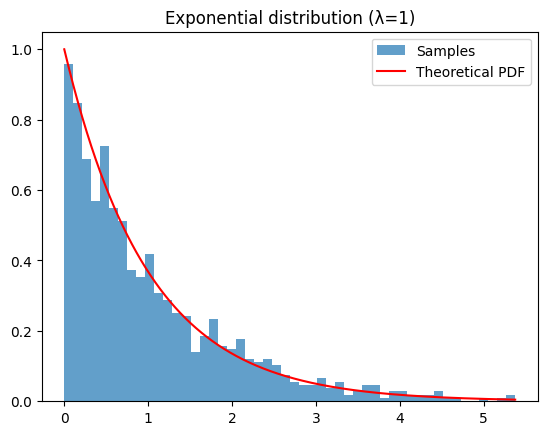

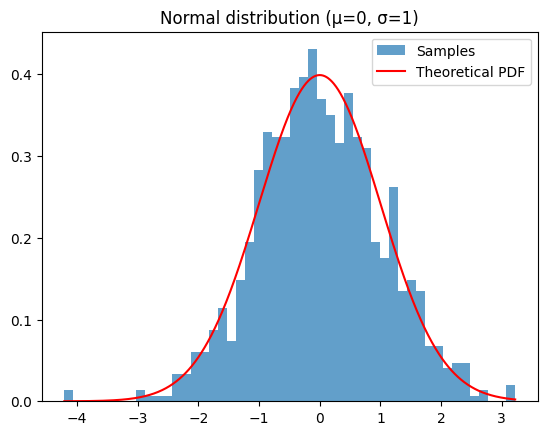

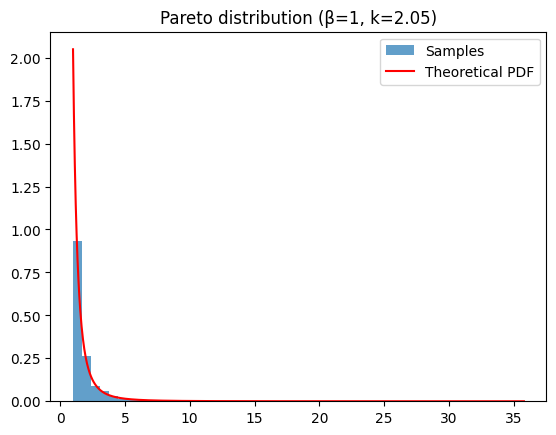

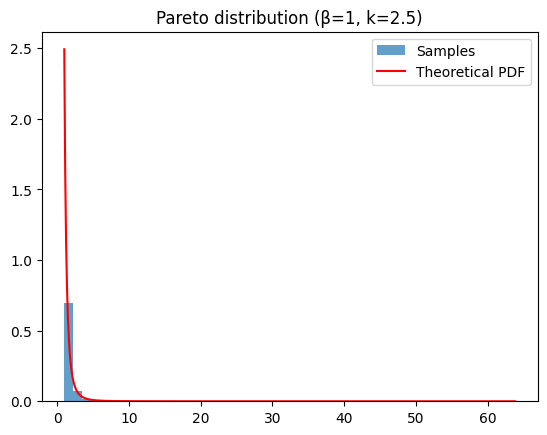

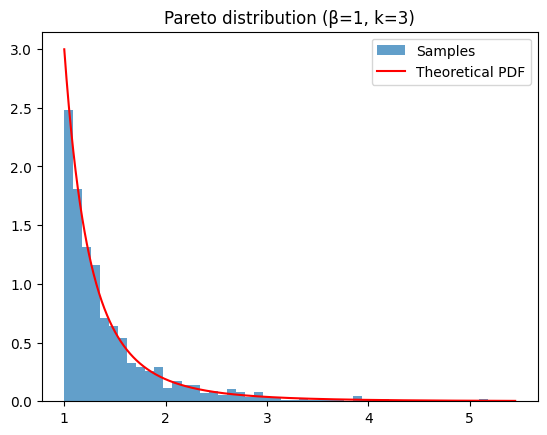

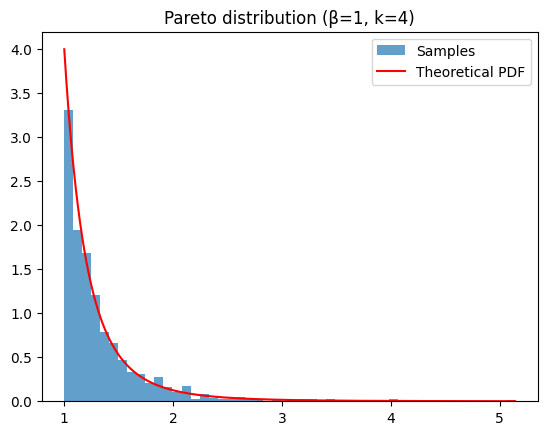

In [3]:
N = 1000

# eponential
exp_samples = [sample_exponential(lam=1) for _ in range(N)]

plt.figure()
plt.hist(exp_samples, bins=50, density=True, alpha=0.7, label='Samples')
x = np.linspace(min(exp_samples), max(exp_samples), 1000)
plt.plot(x, stats.expon(scale=1).pdf(x), 'r-', label='Theoretical PDF')
plt.title('Exponential distribution (λ=1)')
plt.legend()
plt.show()

# normal 
normal_samples = [sample_normal(mu=0, sigma=1) for _ in range(N)]

plt.figure()
plt.hist(normal_samples, bins=50, density=True, alpha=0.7, label='Samples')
x = np.linspace(min(normal_samples), max(normal_samples), 1000)
plt.plot(x, stats.norm(loc=0, scale=1).pdf(x), 'r-', label='Theoretical PDF')
plt.title('Normal distribution (μ=0, σ=1)')
plt.legend()
plt.show()

# pareto 
k_values = [2.05, 2.5, 3, 4]

for k in k_values:
    pareto_samples = [sample_pareto(beta=1, k=k) for _ in range(N)]
    plt.figure()
    plt.hist(pareto_samples, bins=50, density=True, alpha=0.7, label='Samples')
    x = np.linspace(min(pareto_samples), max(pareto_samples), 1000)
    plt.plot(x, stats.pareto(b=k).pdf(x), 'r-', label='Theoretical PDF')
    plt.title(f'Pareto distribution (β=1, k={k})')
    plt.legend()
    plt.show()

## Part 2

In [4]:
beta = 1

def CI_mean(samples, confidence=0.95):
    n = len(samples)
    mean = np.mean(samples)
    S = np.std(samples, ddof=1)
    t_stat = t.ppf(1 - (1-confidence)/2, df=n-1)
    lower = mean - t_stat * S / np.sqrt(n)
    upper = mean + t_stat * S / np.sqrt(n)
    return mean, lower, upper

def CI_std(samples, confidence=0.95):
    n = len(samples)
    S = np.std(samples, ddof=1)
    alpha = 1 - confidence
    lower = np.sqrt((n-1) * S**2 / chi2.ppf(1 - alpha/2, df=n-1))
    upper = np.sqrt((n-1) * S**2 / chi2.ppf(alpha/2, df=n-1))
    return S, lower, upper

for k in k_values:
    samples = [sample_pareto(beta=1, k=k) for _ in range(N)]
    
    mean, mean_lower, mean_upper = CI_mean(samples)
    std, std_lower, std_upper = CI_std(samples)
    
    theoretical_mean = beta * k / (k - 1)
    theoretical_var = beta**2 * k / ((k - 1)**2 * (k - 2))
    
    print(f"Results for k={k}:")
    print(f"  Mean:     {mean:.4f} [{mean_lower:.4f}, {mean_upper:.4f}] (theoretical: {theoretical_mean:.4f})")
    print(f"  Std:      {std:.4f} [{std_lower:.4f}, {std_upper:.4f}] (theoretical: {np.sqrt(theoretical_var):.4f})")
    print("-" * 40)

Results for k=2.05:
  Mean:     2.0682 [1.8772, 2.2592] (theoretical: 1.9524)
  Std:      3.0779 [2.9487, 3.2191] (theoretical: 6.0982)
----------------------------------------
Results for k=2.5:
  Mean:     1.6964 [1.6074, 1.7854] (theoretical: 1.6667)
  Std:      1.4349 [1.3746, 1.5007] (theoretical: 1.4907)
----------------------------------------
Results for k=3:
  Mean:     1.5195 [1.4476, 1.5915] (theoretical: 1.5000)
  Std:      1.1593 [1.1106, 1.2125] (theoretical: 0.8660)
----------------------------------------
Results for k=4:
  Mean:     1.3245 [1.2975, 1.3516] (theoretical: 1.3333)
  Std:      0.4357 [0.4174, 0.4557] (theoretical: 0.4714)
----------------------------------------


## Part 3

In [5]:
def confidence_intervals(num_intervals=100, n=10, confidence=0.95):
    alpha = 1 - confidence
    # Critical values
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)
    chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)
    
    mean_hits = 0
    var_hits = 0
    
    # Normal distribution parameters
    mu_true, var_true = 0, 1
    
    for _ in range(num_intervals):
        data = np.random.normal(mu_true, np.sqrt(var_true), n)
        s_mean = np.mean(data)
        s_var = np.var(data, ddof=1)
        
        # Confidence Interval for the Mean
        ci_mean = (s_mean - t_crit * np.sqrt(s_var/n), s_mean + t_crit * np.sqrt(s_var/n))
        if ci_mean[0] <= mu_true <= ci_mean[1]:
            mean_hits += 1
            
        # Confidence Interval for the Variance
        ci_var = ((n-1)*s_var / chi2_upper, (n-1)*s_var / chi2_lower)
        if ci_var[0] <= var_true <= ci_var[1]:
            var_hits += 1
            
    print(f"Mean Coverage: {mean_hits/num_intervals*100}%")
    print(f"Variance Coverage: {var_hits/num_intervals*100}%")

confidence_intervals()

Mean Coverage: 97.0%
Variance Coverage: 97.0%


## Part 4

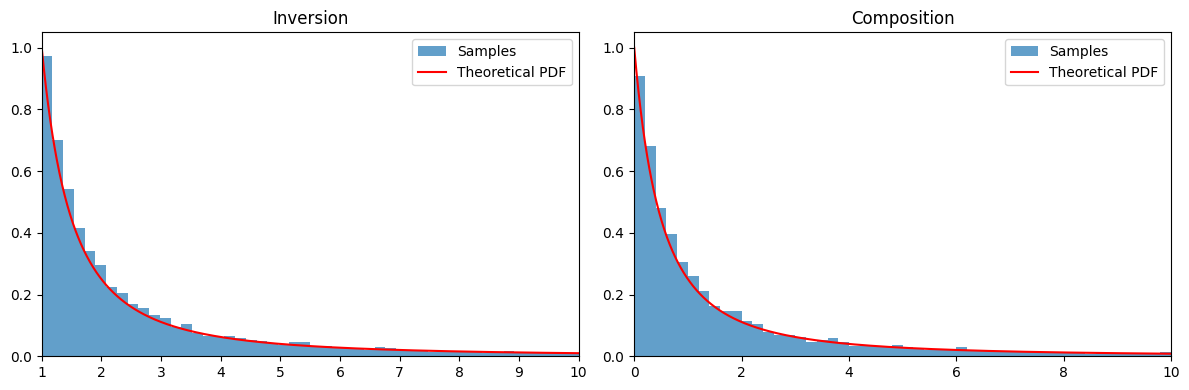

Inverse simulation time: 0.021246910095214844
Composition simulation time: 0.1123819351196289


In [6]:
def sample_pareto_composition(mu):
    y = sample_exponential(lam=mu)
    x = sample_exponential(lam=y)
    return x

N = 10000
mu = 1

start = time.time()
samples_inversion   = [sample_pareto(beta=1, k=1) for _ in range(N)]
inverse_time = time.time() - start


start = time.time()
samples_composition = [sample_pareto_composition(mu=1) for _ in range(N)]
composition_time = time.time() - start

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# inversion method on [1, inf)
x1 = np.linspace(1, 10, 1000)
axes[0].hist(samples_inversion, bins=50, density=True, alpha=0.7, range=(1, 10), label='Samples')
axes[0].plot(x1, stats.pareto(b=1).pdf(x1), 'r-', label='Theoretical PDF')
axes[0].set_xlim(1, 10)
axes[0].set_title('Inversion')
axes[0].legend()

# composition method on [0, inf)
x2 = np.linspace(0, 10, 1000)
axes[1].hist(samples_composition, bins=50, density=True, alpha=0.7, range=(0, 10), label='Samples')
axes[1].plot(x2, mu / (mu + x2)**2, 'r-', label='Theoretical PDF')
axes[1].set_xlim(0, 10)
axes[1].set_title('Composition')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Inverse simulation time:",inverse_time)
print("Composition simulation time:",composition_time)

In [7]:
result = ks_2samp(
    samples_inversion,
    samples_composition
)

print(result)

KstestResult(statistic=np.float64(0.5057), pvalue=np.float64(0.0), statistic_location=np.float64(0.9997986763854905), statistic_sign=np.int8(-1))
